# Nuclear NPV simulation

Run the nuclear electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_technology_npv,
)


In [2]:
TECHNOLOGY = 'nuclear'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_electricity_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,nuclear,1000000.0,5300.0,188.679245,188679.245283,13739.560486,120.424503,7.006475,2.854137,...,94070000.0,2.272160e+07,7.006475e+06,2.283310e+07,0.0,4.150883e+07,-2.149272e+09,25000000.0,-85.970899,-0.000086
1,1,nuclear,1000000.0,5300.0,188.679245,188679.245283,10388.784398,121.136220,6.985556,2.842706,...,94070000.0,2.285589e+07,6.985556e+06,2.274165e+07,0.0,4.148690e+07,-1.517285e+09,25000000.0,-60.691385,-0.000061
2,2,nuclear,1000000.0,5300.0,188.679245,188679.245283,14585.979199,103.618383,8.115047,2.912266,...,94070000.0,1.955064e+07,8.115047e+06,2.329813e+07,0.0,4.310619e+07,-2.291923e+09,25000000.0,-91.676905,-0.000092
3,3,nuclear,1000000.0,5300.0,188.679245,188679.245283,12973.680291,95.838715,7.338033,2.905886,...,94070000.0,1.808278e+07,7.338033e+06,2.324709e+07,0.0,4.540211e+07,-1.963207e+09,25000000.0,-78.528276,-0.000079
4,4,nuclear,1000000.0,5300.0,188.679245,188679.245283,6941.773479,110.225892,7.771694,2.907850,...,94070000.0,2.079734e+07,7.771694e+06,2.326280e+07,0.0,4.223817e+07,-8.588856e+08,25000000.0,-34.355424,-0.000034


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-1602.011666,-64.080467
std,544.910199,21.796408
min,-2600.968013,-104.038721
5%,-2449.437776,-97.977511
50%,-1605.434428,-64.217377
95%,-751.345676,-30.053827
max,-605.401280,-24.216051


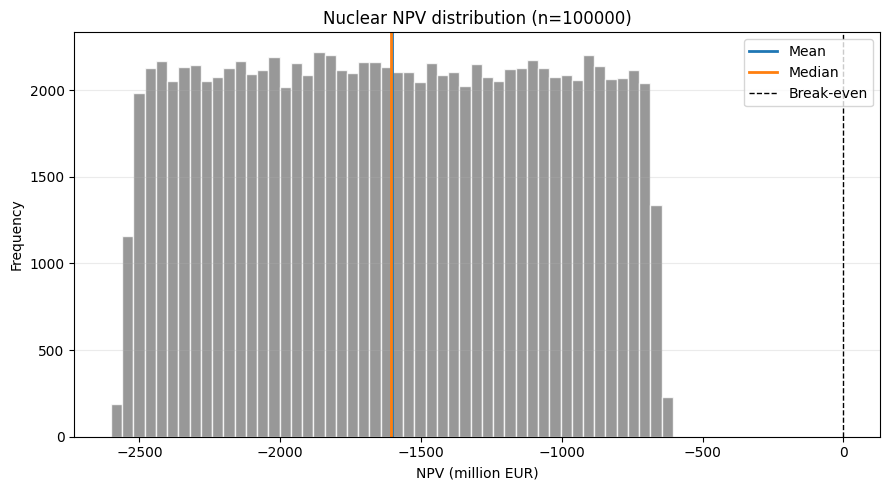

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


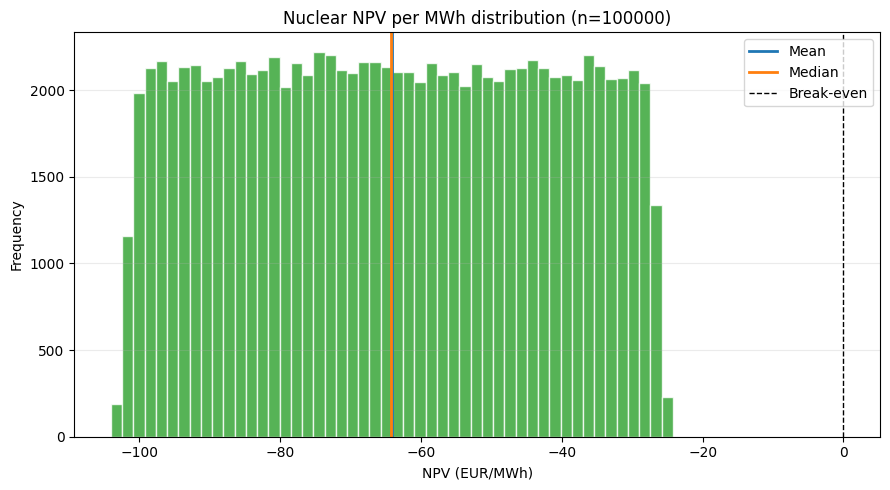

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        19.494106
annual_variable_opex_eur      7.234421
annual_fuel_cost_eur         22.877857
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     44.463617
Name: Mean annual value, million EUR, dtype: float64